# Differential Equations 4: Euler Method

In notebook [Differential_Equations_03](Differential_Equations_03.ipynb), we used the `scipy.integrate.solve_ivp` function to numerically solve some differential equations, both for equations we already knew the answer to (because they were analytically solvable), as well as for equations that were otherwise impossible to solve. 
 
We now take a step back and understand a little of how functions such as `solve_ivp` work under-the-hood. 
 
# Contents 
 1. Euler Method
 

# Imports 

In [3]:
# Standard Imports 
import matplotlib.pyplot as plt
import numpy as np

# The scipy.integrate.solve_ivp function we will use for solving 
from scipy.integrate import solve_ivp

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


# 1. Euler Method

## Resources 

There are a number of useful webpages & videos to help understand this in more detail: 
 - Webpages: 
   - https://tutorial.math.lamar.edu/Classes/DE/EulersMethod.aspx
   -  https://medium.com/@vikramsetty169/solving-second-order-odes-using-eulers-method-python-cb77abb89efe
 - Python notebook: https://pythonnumericalmethods.berkeley.edu/notebooks/chapter22.03-The-Euler-Method.html
 - Youtube video: https://www.youtube.com/watch?v=cdUpAuGTIfE


## Background

Consider an ordinary differential equation

$\frac{dy}{dt} = f(t,y)$

Assume we know 

 - The functional form of the *derivative*, $f(t,y)$

 - $y(t_0) = y_0$

 - $\left.\frac{dy}{dt}\right|_{t=t_0} = f(t_0,y_0)$
 
We want to find $y(t)$


## Explicit Euler Formula

Basic calculus says that 

$y(t_{i+1}) = y(t_{i}) + (t_{i+1} - t_{i})\left.\frac{dy}{dt}\right|_{t_i}$

or

$y(t_{i+1}) = y(t_{i}) + h \cdot f\left(t_i,y(t_{i})\right)$
 
This allows us to compute an approximation for the 'next' state, $y(t_{i+1})$, if we know the current state, $y(t_{i})$ and its derivate, $f\left(t_i,y(t_{i})\right)$. 

In [18]:
def euler_explicit( dydt, t_span, init, args=(), h=1e-3):
    """ 
    A function that implements the Explicit Euler Formula
    Deliberately written to have a call signature that is similar to `solve_ivp` 
    
    inputs:
    -------
    dydt: function
    
    t_span: tuple 
     - the start & end times 
    
    init: 
     - inital value of y
    
    args=():  
     - any arguments to be passed to dydt
     
    h=1e-6: 
     - step size
    
    """
    # Check inputs 
    assert t_span[1] > t_span[0]
    assert len(t_span) == 2 
    
    times = np.arange(t_span[0], t_span[1] + h, h)   # <-- An array of evaluation times
    y     = np.zeros( len(times) )                   # <-- An array to hold the results for y(t) 
    y[0]  = init[0]                                  # <-- The initial value of y(t=t_0)
    for i,t in enumerate(times[:-1]):                # <-- Iterate over all timesteps 
        y[i+1] = y[i] + h * dydt(t, y[i], *args)     # <-- Implement Explicit Euler step 
    return times, y 


### 1.1 Exponential Growth

Let's apply our `euler_explicit` function to the exponential growth equation we modelled in notebooks [Differential_Equations_02_Why.ipynb](Differential_Equations_02_Why.ipynb) & [Differential_Equations_03.ipynb](Differential_Equations_03.ipynb)

We see that: ...
 - For large step sizes `euler_explicit` gives poor results  

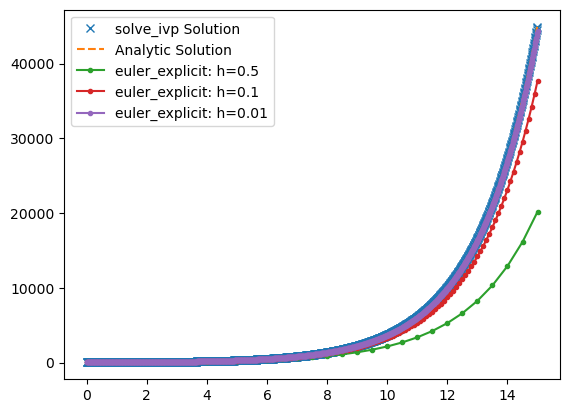

In [19]:
# Consider the eqn dN/dt = rN from the notebook Differential_Equations_02_Why.ipynb
def dNdt(t, y, growth_rate):
    return growth_rate*y


# Define the initial values of N & the growth-rate 
init_popn = [25.0]
growth_rate = 0.5

# Define the time-span over which we want the solution to be calculated 
t_span = [0,15]

# Call solve_ivp
sol = solve_ivp(dNdt, t_span, init_popn, args=(growth_rate,), dense_output=True )

# Time points for plotting 
t = np.arange(0,15,0.01) 

# Plot the numerical solution from solve_ivp
plt.plot(t, sol.sol(t)[0], 'x', label="solve_ivp Solution")

# Plot the analytic solution 
#  N = init_popn*np.exp(growth_rate*t)
plt.plot(t, init_popn*np.exp(growth_rate*t), '--', label="Analytic Solution")


for h in [0.5, 0.1, 0.01]:
    # Call euler_explicit
    eul = euler_explicit(dNdt, t_span, init_popn, args=(growth_rate,), h=h)

    # Plot the numerical solution from euler_explicit
    plt.plot(eul[0], eul[1], '.-', label=f"euler_explicit: h={h}")


_=plt.legend() 



# Exercise (A)

In Exercise (A) of notebook [Differential_Equations_03.ipynb](Differential_Equations_03.ipynb) you were asked to solve the Logistic Differential Equation and use the ipywidgets.interact function to make a dynamic plot that allows you vary the values of $r$, $K$ & $P_0$ using sliders, and use it to compare your analytic & numerical solutions from (1) & (2) as you vary the parameters. 

Reuse this solution and add into it solutions to the Logistic Differential Equation that use the `euler_explicit` function. 

Plot comparisons between analytic solutions, `solve_ivp` solutions and `euler_explicit` solutions (for a few different values of $h$ in the `euler_explicit` function). 

## Backward/Implicit Euler Method 

The Implicit Euler Formula can be derived by taking the linear approximation of $y(t)$ around $t_{i+1}$ and computing it at $t_j$: 

$y(t_{i+1}) = y(t_{i}) + h \cdot f\left(t_{j+1},y(t_{i+1})\right)$

This formula is peculiar because it requires that we know $y(t_{i+1})$ to compute $y(t_{i+1})$!

However, it happens that sometimes we *can* use this formula to approximate the solution to initial value problems. 

#### Example for Exponential growth model:

Consider our exponential growth example, where $\frac{dN}{dt} = f(t,N) = rN$, and we are trying to find $N(t)$.

Substituting this into $N(t_{i+1}) = N(t_{i}) + h \cdot f\left(t_{j+1},y(t_{i+1})\right)$, we find:

$N(t_{i+1}) = N(t_{i}) + h \cdot rN(t_{i+1})$.

Rearranging, we get 

$N(t_{i+1})\left(1 - rh\right) = N(t_{i})$

or

$N(t_{i+1}) = \frac{ N(t_{i}) }{ \left(1 - rh\right)} $

This is the form of equation we can use in a numerical solver ... 